# QSAR Aromatase â€” Classification (16 Models x 12 Fingerprints x 2 Splits)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dom-castaneda/qsar-aromatase/blob/master/notebooks/colab_qsar_classification_reduced.ipynb)

**Target**: Bioactivity class prediction for Aromatase (CYP19A1) inhibitors
- **active**: pchembl > 7
- **intermediate**: 6 <= pchembl <= 7
- **inactive**: pchembl < 6

**Total runs**: 16 x 12 x 2 = 384 model fits + 10-fold CV
**Metrics**: Accuracy, Balanced Accuracy, F1 (weighted), MCC on train, 10-fold CV, and test sets
**Class imbalance**: Handled via class_weight='balanced' where supported

| Class | Count | Ratio |
|-------|-------|-------|
| inactive | 1,393 | 1.50x |
| active | 966 | 1.04x |
| intermediate | 931 | 1.00x |

**16 classifiers** (equivalent to the 16 regressors in the regression notebook):

| # | Regression | Classification Equivalent |
|---|-----------|--------------------------|
| 1 | Ridge | Ridge Classifier |
| 2 | Lasso | Logistic Regression (L1) |
| 3 | ElasticNet | Logistic Regression (ElasticNet) |
| 4 | Bayesian Ridge | Naive Bayes (Gaussian) |
| 5 | PLS | Linear Discriminant Analysis |
| 6 | KNN Regressor | KNN Classifier |
| 7 | SVR (RBF) | SVC (RBF) |
| 8 | Kernel Ridge (RBF) | SVC (Linear) |
| 9 | Decision Tree | Decision Tree Classifier |
| 10 | Random Forest | Random Forest Classifier |
| 11 | Extra Trees | Extra Trees Classifier |
| 12 | Gradient Boosting | Gradient Boosting Classifier |
| 13 | XGBoost | XGBoost Classifier |
| 14 | Hist Gradient Boosting | Hist Gradient Boosting Classifier |
| 15 | AdaBoost | AdaBoost Classifier |
| 16 | MLP | MLP Classifier |


## 1. Setup â€” Download Data & Install

In [1]:
import os, subprocess, sys

if not os.path.exists("data"):
    !wget -q "https://github.com/dom-castaneda/qsar-aromatase/raw/master/data.zip" -O data.zip
    !unzip -qo data.zip
    print("Data extracted.")
else:
    print("Data present.")

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
print("Setup complete.")


Data extracted.
Setup complete.


## 2. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os, time
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, matthews_corrcoef, classification_report,
                             confusion_matrix)
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, AdaBoostClassifier,
                              HistGradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier

print("All imports OK")


All imports OK


## 3. Load Data

In [3]:
RANDOM_STATE = 42
N_FOLDS = 5
BASE = "data"

FP_NAMES = {
    "MACCS": "fingerprints_maccs.csv",
    "PubChem": "fingerprints_pubchem.csv",
    "Substructure": "fingerprints_substruct.csv",
    "SubstructureCount": "fingerprints_substruct_count.csv",
    "KR": "fingerprints_kr.csv",
    "KR_Count": "fingerprints_kr_count.csv",
    "AtomPairs2D": "fingerprints_atompairs2d.csv",
    "AP2D_Count": "fingerprints_atompairs2d_count.csv",
    "CDK_FP": "fingerprints_cdk_fp.csv",
    "CDK_Extended": "fingerprints_cdk_extended.csv",
    "CDK_GraphOnly": "fingerprints_cdk_graphonly.csv",
    "EState": "fingerprints_estate.csv",
}

SPLITS = {
    "Random": (f"{BASE}/splits/random_train.csv", f"{BASE}/splits/random_test.csv"),
    "Kennard-Stone": (f"{BASE}/splits/kennard_stone_train.csv", f"{BASE}/splits/kennard_stone_test.csv"),
}

# Load base dataset
df_full = pd.read_csv(f"{BASE}/processed/aromatase_bioactivity_clean.csv")
mask = (df_full["standard_relation"] == "=") & df_full["pchembl_value"].notna()
df = df_full[mask].reset_index(drop=True)

# Assign classes: active (>7), intermediate (6-7), inactive (<6)
def classify(val):
    if val > 7: return "active"
    elif val < 6: return "inactive"
    else: return "intermediate"

df["label"] = df["pchembl_value"].apply(classify)
print(f"Dataset: {len(df)} molecules")
print(f"\nClass distribution:")
print(df["label"].value_counts())
print(f"\nImbalance ratio: {df['label'].value_counts().max() / df['label'].value_counts().min():.2f}")

# Load fingerprints
fp_data = {}
for fp_name, fp_file in FP_NAMES.items():
    fp_full = pd.read_csv(f"{BASE}/fingerprints_reduced/{fp_file}")
    fp_filtered = fp_full[mask.values].reset_index(drop=True)
    fp_cols = [c for c in fp_filtered.columns if c != "molecule_chembl_id"]
    X = np.nan_to_num(fp_filtered[fp_cols].values.astype(np.float32), nan=0.0)
    fp_data[fp_name] = X
    print(f"  {fp_name:<20} {X.shape[1]:>5} features")

# Load splits
split_masks = {}
for split_name, (train_file, test_file) in SPLITS.items():
    train_ids = set(pd.read_csv(train_file)["molecule_chembl_id"])
    test_ids = set(pd.read_csv(test_file)["molecule_chembl_id"])
    split_masks[split_name] = (
        df["molecule_chembl_id"].isin(train_ids).values,
        df["molecule_chembl_id"].isin(test_ids).values,
    )

# Encode labels as integers for XGBoost/MLP compatibility
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_all = le.fit_transform(df["label"].values)
label_names = list(le.classes_)  # ['active', 'inactive', 'intermediate']
print(f"Label encoding: {dict(zip(label_names, le.transform(label_names)))}")
print(f"\nReady: {len(FP_NAMES)*len(SPLITS)*16} runs")


Dataset: 3290 molecules

Class distribution:
label
inactive        1393
active           966
intermediate     931
Name: count, dtype: int64

Imbalance ratio: 1.50
  MACCS                  102 features
  PubChem                183 features
  Substructure            38 features
  SubstructureCount       39 features
  KR                     134 features
  KR_Count               128 features
  AtomPairs2D            518 features
  AP2D_Count             455 features
  CDK_FP                1021 features
  CDK_Extended           879 features
  CDK_GraphOnly            9 features
  EState                  24 features
Label encoding: {'active': np.int64(0), 'inactive': np.int64(1), 'intermediate': np.int64(2)}

Ready: 384 runs


## 4. Model Builder (16 Classifiers â€” Equivalent to Regression)

In [4]:
def build_models():
    """16 classifiers matching the 16 regressors in the regression notebook."""
    models = [
        # 1. Ridge -> Ridge Classifier
        ("Ridge Classifier", RidgeClassifier(alpha=1.0, class_weight="balanced")),
        # 2. Lasso -> Logistic Regression L1
        ("Logistic Reg (L1)", LogisticRegression(penalty="l1", solver="saga", C=10.0,
                                                  max_iter=300, class_weight="balanced",
                                                  random_state=RANDOM_STATE)),
        # 3. ElasticNet -> Logistic Regression ElasticNet
        ("Logistic Reg (EN)", LogisticRegression(penalty="elasticnet", solver="saga", C=10.0,
                                                  l1_ratio=0.5, max_iter=300,
                                                  class_weight="balanced", random_state=RANDOM_STATE)),
        # 4. Bayesian Ridge -> Gaussian Naive Bayes
        ("Naive Bayes", GaussianNB()),
        # 5. PLS -> Linear Discriminant Analysis
        ("LDA", LinearDiscriminantAnalysis()),
        # 6. KNN Regressor -> KNN Classifier
        ("KNN", KNeighborsClassifier(n_neighbors=5)),
        # 7. SVR (RBF) -> SVC (RBF)
        ("SVC (RBF)", SVC(kernel="rbf", C=1.0, class_weight="balanced", max_iter=300, random_state=RANDOM_STATE)),
        # 8. Kernel Ridge (RBF) -> SVC (linear) as kernel method equivalent
        #    (GaussianProcessClassifier is O(n^3) and too slow for 3k samples x 12 FPs x CV)
        ("SVC (Linear)", SVC(kernel="linear", C=1.0, class_weight="balanced", max_iter=300, random_state=RANDOM_STATE)),
        # 9. Decision Tree -> Decision Tree Classifier
        ("Decision Tree", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
        # 10. Random Forest -> Random Forest Classifier
        ("Random Forest", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                  random_state=RANDOM_STATE, n_jobs=-1)),
        # 11. Extra Trees -> Extra Trees Classifier
        ("Extra Trees", ExtraTreesClassifier(n_estimators=200, class_weight="balanced",
                                              random_state=RANDOM_STATE, n_jobs=-1)),
        # 12. Gradient Boosting -> Gradient Boosting Classifier
        ("Gradient Boosting", GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)),
        # 13. XGBoost -> XGBoost Classifier
        ("XGBoost", XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE,
                                   verbosity=0, n_jobs=-1, eval_metric="mlogloss")),
        # 14. Hist Gradient Boosting -> Hist Gradient Boosting Classifier
        ("Hist Gradient Boosting", HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE)),
        # 15. AdaBoost -> AdaBoost Classifier
        ("AdaBoost", AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE)),
        # 16. MLP Regressor -> MLP Classifier
        ("MLP", MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300,
                               random_state=RANDOM_STATE, early_stopping=True)),
    ]
    return models


def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_true, y_pred)
    return acc, bal_acc, f1, mcc

print(f"{len(build_models())} classifiers defined.")
print("Models with class_weight='balanced': Ridge, LogReg(L1), LogReg(EN), SVC(RBF), SVC(Linear), DT, RF, ET")


16 classifiers defined.
Models with class_weight='balanced': Ridge, LogReg(L1), LogReg(EN), SVC(RBF), SVC(Linear), DT, RF, ET


## 5. Training Loop

In [5]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
all_results = []
total_runs = len(SPLITS) * len(FP_NAMES) * 16
run_count = 0
t_start = time.time()

for split_name, (train_mask, test_mask) in split_masks.items():
    y_train, y_test = y_all[train_mask], y_all[test_mask]

    for fp_name, X_fp in fp_data.items():
        X_train, X_test = X_fp[train_mask], X_fp[test_mask]

        for model_name, model in build_models():
            run_count += 1
            t0 = time.time()

            try:
                # 10-fold CV
                try:
                    y_cv = cross_val_predict(model, X_train, y_train, cv=kf, n_jobs=1)
                    acc_cv, bal_cv, f1_cv, mcc_cv = compute_metrics(y_train, y_cv)
                except Exception:
                    acc_cv, bal_cv, f1_cv, mcc_cv = np.nan, np.nan, np.nan, np.nan

                # Fit on full training set
                model.fit(X_train, y_train)

                # Train metrics
                y_train_pred = model.predict(X_train)
                acc_tr, bal_tr, f1_tr, mcc_tr = compute_metrics(y_train, y_train_pred)

                # Test metrics
                y_test_pred = model.predict(X_test)
                acc_te, bal_te, f1_te, mcc_te = compute_metrics(y_test, y_test_pred)

                elapsed = time.time() - t0
                all_results.append({
                    "Split": split_name, "Fingerprint": fp_name, "Model": model_name,
                    "Acc_train": acc_tr, "BalAcc_train": bal_tr, "F1_train": f1_tr, "MCC_train": mcc_tr,
                    "Acc_CV": acc_cv, "BalAcc_CV": bal_cv, "F1_CV": f1_cv, "MCC_CV": mcc_cv,
                    "Acc_test": acc_te, "BalAcc_test": bal_te, "F1_test": f1_te, "MCC_test": mcc_te,
                    "Time_s": elapsed,
                })

            except Exception as e:
                elapsed = time.time() - t0
                all_results.append({
                    "Split": split_name, "Fingerprint": fp_name, "Model": model_name,
                    "Acc_train": np.nan, "BalAcc_train": np.nan, "F1_train": np.nan, "MCC_train": np.nan,
                    "Acc_CV": np.nan, "BalAcc_CV": np.nan, "F1_CV": np.nan, "MCC_CV": np.nan,
                    "Acc_test": np.nan, "BalAcc_test": np.nan, "F1_test": np.nan, "MCC_test": np.nan,
                    "Time_s": elapsed,
                })
                print(f"  FAILED: {split_name}/{fp_name}/{model_name}: {e}")

            if True:
                et = time.time() - t_start
                print(f"  [{run_count}/{total_runs}] {split_name}|{fp_name}|{model_name} "
                      f"BalAcc={all_results[-1]['BalAcc_test']:.4f} "
                      f"({et:.0f}s, ETA ~{(et/run_count)*(total_runs-run_count)/60:.0f}min)")

print(f"\nDONE: {run_count} runs in {(time.time()-t_start)/60:.1f} min")


  [1/384] Random|MACCS|Ridge Classifier BalAcc=0.5346 (0s, ETA ~1min)
  [2/384] Random|MACCS|Logistic Reg (L1) BalAcc=0.5481 (29s, ETA ~92min)
  [3/384] Random|MACCS|Logistic Reg (EN) BalAcc=0.5481 (47s, ETA ~99min)
  [4/384] Random|MACCS|Naive Bayes BalAcc=0.4343 (47s, ETA ~74min)
  [5/384] Random|MACCS|LDA BalAcc=0.5547 (47s, ETA ~60min)
  [6/384] Random|MACCS|KNN BalAcc=0.6189 (48s, ETA ~50min)
  [7/384] Random|MACCS|SVC (RBF) BalAcc=0.3459 (50s, ETA ~45min)
  [8/384] Random|MACCS|SVC (Linear) BalAcc=0.3678 (51s, ETA ~40min)
  [9/384] Random|MACCS|Decision Tree BalAcc=0.6070 (51s, ETA ~35min)
  [10/384] Random|MACCS|Random Forest BalAcc=0.6340 (56s, ETA ~35min)
  [11/384] Random|MACCS|Extra Trees BalAcc=0.6263 (64s, ETA ~36min)
  [12/384] Random|MACCS|Gradient Boosting BalAcc=0.6080 (90s, ETA ~47min)
  [13/384] Random|MACCS|XGBoost BalAcc=0.6257 (94s, ETA ~45min)
  [14/384] Random|MACCS|Hist Gradient Boosting BalAcc=0.6268 (125s, ETA ~55min)
  [15/384] Random|MACCS|AdaBoost BalAcc=0

## 6. Save Results

In [6]:
results_df = pd.DataFrame(all_results)
results_df.to_csv("results_classification_reduced.csv", index=False)
n_ok = results_df["Acc_test"].notna().sum()
print(f"Saved: results_classification_reduced.csv ({n_ok}/{len(results_df)} successful)")
print(f"Columns: {list(results_df.columns)}")
results_df.sort_values("BalAcc_test", ascending=False).head(20)


Saved: results_classification_reduced.csv (384/384 successful)
Columns: ['Split', 'Fingerprint', 'Model', 'Acc_train', 'BalAcc_train', 'F1_train', 'MCC_train', 'Acc_CV', 'BalAcc_CV', 'F1_CV', 'MCC_CV', 'Acc_test', 'BalAcc_test', 'F1_test', 'MCC_test', 'Time_s']


,Split,Fingerprint,Model,Acc_train,BalAcc_train,F1_train,MCC_train,Acc_CV,BalAcc_CV,F1_CV,MCC_CV,Acc_test,BalAcc_test,F1_test,MCC_test,Time_s
122,Random,AP2D_Count,Extra Trees,0.920571,0.919204,0.921626,0.881666,0.668375,0.649466,0.667785,0.493257,0.695251,0.688251,0.697184,0.540104,12.624029
105,Random,AtomPairs2D,Random Forest,0.920571,0.917253,0.921220,0.879553,0.653001,0.629202,0.647214,0.467807,0.695251,0.685815,0.693274,0.538715,10.023024
316,Kennard-Stone,AP2D_Count,XGBoost,0.944084,0.935845,0.943658,0.914038,0.677489,0.651379,0.673051,0.501530,0.687970,0.684038,0.684390,0.528478,20.059847
109,Random,AtomPairs2D,Hist Gradient Boosting,0.920571,0.912529,0.920183,0.878715,0.656296,0.636730,0.654270,0.474180,0.696570,0.683588,0.689363,0.540924,120.788655
106,Random,AtomPairs2D,Extra Trees,0.920571,0.919204,0.921626,0.881666,0.656296,0.635069,0.653939,0.473563,0.689974,0.682197,0.690859,0.531505,14.058384
125,Random,AP2D_Count,Hist Gradient Boosting,0.920571,0.913226,0.920393,0.878721,0.661420,0.641759,0.660035,0.482423,0.693931,0.681930,0.689566,0.536371,107.364627
300,Kennard-Stone,AtomPairs2D,XGBoost,0.954545,0.948597,0.954368,0.930085,0.663059,0.635770,0.657662,0.478913,0.685464,0.681584,0.681402,0.525109,15.014496
121,Random,AP2D_Count,Random Forest,0.920571,0.917038,0.921184,0.879492,0.660688,0.639486,0.657765,0.480413,0.688654,0.680184,0.686913,0.528758,11.604762
108,Random,AtomPairs2D,XGBoost,0.920205,0.911696,0.919720,0.878156,0.655564,0.635466,0.652525,0.472380,0.691293,0.677534,0.682277,0.533355,14.935088
124,Random,AP2D_Count,XGBoost,0.914348,0.903757,0.913288,0.869487,0.666179,0.644887,0.662730,0.488801,0.689974,0.676736,0.680485,0.531556,17.599646


## 7. Best Models Summary

In [7]:
print("=" * 90)
print(f"{'BEST MODEL PER FINGERPRINT (by test Balanced Accuracy)':^90}")
print("=" * 90)

valid = results_df.dropna(subset=["BalAcc_test"])

for split_name in SPLITS:
    print(f"\n--- {split_name} Split ---")
    sub = valid[valid["Split"] == split_name]
    best_per_fp = sub.loc[sub.groupby("Fingerprint")["BalAcc_test"].idxmax()]
    best_per_fp = best_per_fp.sort_values("BalAcc_test", ascending=False)
    print(f"{'Fingerprint':<20} {'Model':<22} {'Acc':<8} {'BalAcc':<8} {'F1':<8} {'MCC':<8}")
    print("-" * 75)
    for _, row in best_per_fp.iterrows():
        print(f"{row['Fingerprint']:<20} {row['Model']:<22} {row['Acc_test']:<8.4f} "
              f"{row['BalAcc_test']:<8.4f} {row['F1_test']:<8.4f} {row['MCC_test']:<8.4f}")

best = valid.loc[valid["BalAcc_test"].idxmax()]
print(f"\nOVERALL BEST: {best['Model']} on {best['Fingerprint']} ({best['Split']})")
print(f"  Accuracy={best['Acc_test']:.4f}, Balanced Acc={best['BalAcc_test']:.4f}, "
      f"F1={best['F1_test']:.4f}, MCC={best['MCC_test']:.4f}")


                  BEST MODEL PER FINGERPRINT (by test Balanced Accuracy)                  

--- Random Split ---
Fingerprint          Model                  Acc      BalAcc   F1       MCC     
---------------------------------------------------------------------------
AP2D_Count           Extra Trees            0.6953   0.6883   0.6972   0.5401  
AtomPairs2D          Random Forest          0.6953   0.6858   0.6933   0.5387  
CDK_Extended         XGBoost                0.6873   0.6748   0.6785   0.5274  
CDK_FP               Hist Gradient Boosting 0.6781   0.6666   0.6682   0.5141  
KR_Count             Extra Trees            0.6728   0.6662   0.6752   0.5064  
PubChem              Extra Trees            0.6596   0.6547   0.6602   0.4873  
SubstructureCount    Extra Trees            0.6596   0.6524   0.6637   0.4889  
MACCS                Random Forest          0.6398   0.6340   0.6398   0.4571  
KR                   Random Forest          0.6398   0.6328   0.6385   0.4565  
Substructur

## 8. Confusion Matrix (Best Model)

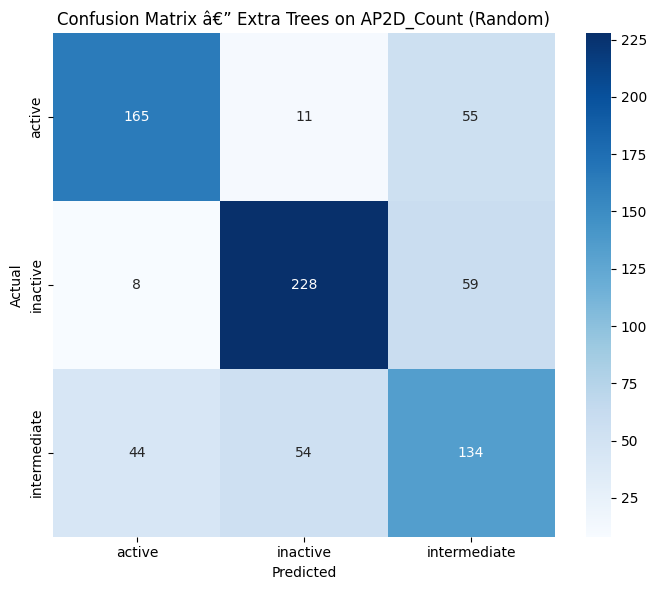


Classification Report:
              precision    recall  f1-score   support

      active       0.76      0.71      0.74       231
    inactive       0.78      0.77      0.78       295
intermediate       0.54      0.58      0.56       232

    accuracy                           0.70       758
   macro avg       0.69      0.69      0.69       758
weighted avg       0.70      0.70      0.70       758



In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Retrain best model for confusion matrix
best_split = best["Split"]
best_fp = best["Fingerprint"]
best_model_name = best["Model"]

train_mask, test_mask = split_masks[best_split]
X_train = fp_data[best_fp][train_mask]
X_test = fp_data[best_fp][test_mask]
y_train_cm = y_all[train_mask]
y_test_cm = y_all[test_mask]

# Rebuild the best model
for name, model in build_models():
    if name == best_model_name:
        model.fit(X_train, y_train_cm)
        y_pred_cm = model.predict(X_test)
        break

labels = list(range(len(label_names)))
cm = confusion_matrix(y_test_cm, y_pred_cm, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix â€” {best_model_name} on {best_fp} ({best_split})")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_cm, y_pred_cm, target_names=label_names))


## 9. Heatmaps â€” Balanced Accuracy (Model x Fingerprint)

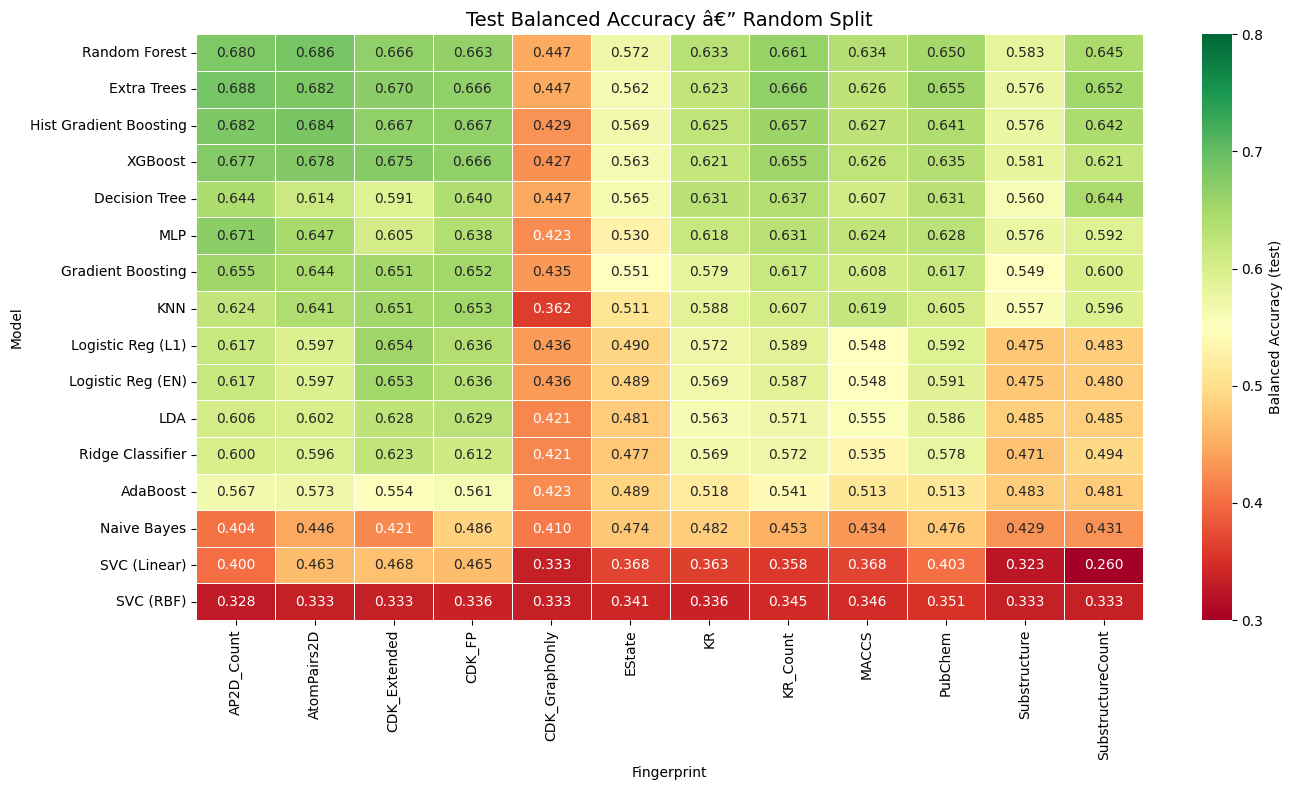

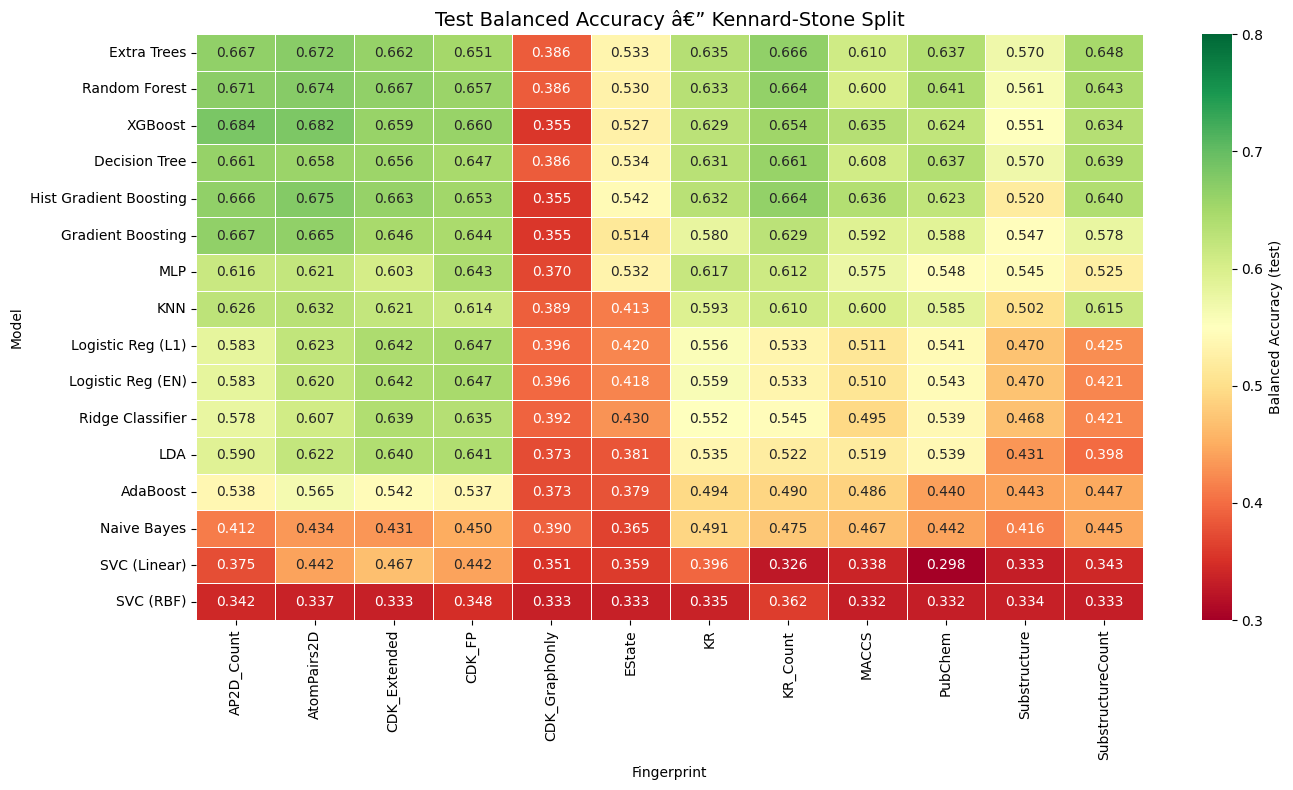

In [9]:
for split_name in SPLITS:
    sub = valid[valid["Split"] == split_name]
    pivot = sub.pivot_table(index="Model", columns="Fingerprint", values="BalAcc_test")
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.3, vmax=0.8,
                linewidths=0.5, ax=ax, cbar_kws={"label": "Balanced Accuracy (test)"})
    ax.set_title(f"Test Balanced Accuracy â€” {split_name} Split", fontsize=14)
    plt.tight_layout()
    fname = f"heatmap_balacc_{split_name.lower().replace('-','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()


## 10. Download

In [10]:
from google.colab import files
files.download("results_classification_reduced.csv")
print("Done.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.
